# ==============================================================================
# REQUIRED LIBRARIES
# ==============================================================================

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.optimizers import Adam
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

I0000 00:00:1773245580.088406   54088 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773245580.569710   54088 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773245582.042191   54088 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# ==============================================================================
# DATA PREPROCESSING
# ==============================================================================


In [2]:
# Define the column names for the NSL-KDD dataset
column_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label", "difficulty"
]

# --- LOCAL FILE PATHS ---
# Load datasets directly from the local file system.
train_path = "KDDTrain+.csv"
test_path = "KDDTest+.csv"

df_train = pd.read_csv(train_path, header=None, names=column_names)
df_test = pd.read_csv(test_path, header=None, names=column_names)
# ------------------------

In [3]:
# The 'difficulty' column is not required for model training and is dropped.
df_train.drop("difficulty", axis=1, inplace=True)
df_test.drop("difficulty", axis=1, inplace=True)

print('Dimensions of the Training set:', df_train.shape)
print('Dimensions of the Test set:', df_test.shape)

# Check for missing values 
print("\nChecking for Null Values:")
print(f"Total Null values in Training set: {df_train.isna().sum().sum()}")
print(f"Total Null values in Test set: {df_test.isna().sum().sum()}")

Dimensions of the Training set: (125973, 42)
Dimensions of the Test set: (22543, 42)

Checking for Null Values:
Total Null values in Training set: 0
Total Null values in Test set: 0


In [4]:
def group_attack_labels(df):
    """
    Groups the 42 unique attack labels into 5 main categories (DoS, R2L, Probe, U2R, Normal).
    Fixes the Pandas SettingWithCopyWarning by explicitly assigning the modified series back.
    """
    labels = df['label'].copy()

    # Denial of Service (DoS) attacks
    labels.replace([
        'apache2','back','land','neptune','mailbomb','pod','processtable',
        'smurf','teardrop','udpstorm','worm'
    ], 'DoS', inplace=True)

    # Remote to Local (R2L) attacks
    labels.replace([
        'ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf',
        'sendmail','snmpgetattack','snmpguess','spy','warezclient','warezmaster',
        'xlock','xsnoop'
    ], 'R2L', inplace=True)

    # Probing attacks
    labels.replace([
        'ipsweep','mscan','nmap','portsweep','saint','satan'
    ], 'Probe', inplace=True)

    # User to Root (U2R) attacks
    labels.replace([
        'buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'
    ], 'U2R', inplace=True)
    
    df['label'] = labels # Assign the modified series back to the DataFrame
    
group_attack_labels(df_train)
group_attack_labels(df_test)


# Separate features (X) and labels (y)
X_train = df_train.drop(['label'], axis=1)
y_train = df_train['label']
X_test = df_test.drop(['label'], axis=1)
y_test = df_test['label']


# ==============================================================================
# FEATURE ENGINEERING: ENCODING AND SCALING
# ==============================================================================

In [5]:
# Identify categorical and numerical columns for preprocessing
categorical_cols = ['protocol_type', 'service', 'flag']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# Fit the preprocessor ONLY on the training data, then transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert the sparse matrices to dense NumPy arrays immediately.
# This prevents the AttributeError later in the sampling functions.
if hasattr(X_train_processed, 'toarray'):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, 'toarray'):
    X_test_processed = X_test_processed.toarray()

In [6]:
# Label Encoding for output classes (y_train, y_test)
le = LabelEncoder()
le.fit(pd.concat([df_train['label'], df_test['label']], axis=0))

y_train_encoded = le.transform(df_train['label'])
y_test_encoded = le.transform(df_test['label'])

# Convert integer labels to one-hot categorical format for Keras/TensorFlow
num_classes = len(le.classes_)
y_train_cat = tf.keras.utils.to_categorical(y_train_encoded, num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(y_test_encoded, num_classes=num_classes)


In [7]:
# Display the class-to-integer mapping for verification
print("\nClass-to-Integer Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i} -> {cls}")

print('\nDimensions of the Processed Training set:', X_train_processed.shape)
print('Dimensions of the Processed Test set:', X_test_processed.shape)


Class-to-Integer Mapping:
0 -> DoS
1 -> Probe
2 -> R2L
3 -> U2R
4 -> normal

Dimensions of the Processed Training set: (125973, 122)
Dimensions of the Processed Test set: (22543, 122)


# ==============================================================================
# UTILITY FUNCTION: EXTRACT SINGLE PRE-PROCESSED INPUT
# ==============================================================================

In [8]:
def get_sample_vector(row_idx=None, class_name=None, class_instance=0):
    """
    Extracts and prints a single pre-processed input vector in C-style array format.
    """

    if row_idx is not None:
        idx = row_idx
    elif class_name is not None:
        encoded_class = le.transform([class_name])[0]
        indices = np.where(y_test_encoded == encoded_class)[0]
        
        if len(indices) == 0:
            raise ValueError(f"No samples found for class '{class_name}'")
        if class_instance >= len(indices):
            raise ValueError(f"Requested instance {class_instance} (0-indexed) "
                             f"but only {len(indices)} samples exist for class '{class_name}'")
        idx = indices[class_instance]
    else:
        raise ValueError("You must specify either row_idx or class_name.")

    row_dense = X_test_processed[idx].flatten()

    print("\n// C-Style Input Vector")
    print("{")
    print(", ".join([f"{x:.6f}f" for x in row_dense]))
    print("};")

    true_label_enc = y_test_encoded[idx]
    true_label_name = le.inverse_transform([true_label_enc])[0]
    print(f"\nRow index (in X_test_processed): {idx}")
    print(f"True label (encoded): {true_label_enc}")
    print(f"Label name: {true_label_name}")

# Extract and print one sample for each major class, this is used for debugging in RTL
print("\n" + "="*50)
print("EXTRACTING SAMPLE INPUT VECTORS FOR C/VERILOG DEBUGGING")
get_sample_vector(class_name="normal", class_instance=0)
get_sample_vector(class_name="DoS", class_instance=0)
get_sample_vector(class_name="Probe", class_instance=0)
get_sample_vector(class_name="R2L", class_instance=99)
get_sample_vector(class_name="U2R", class_instance=0)
print("="*50)


EXTRACTING SAMPLE INPUT VECTORS FOR C/VERILOG DEBUGGING

// C-Style Input Vector
{
0.000000f, 1.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 1.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 1.000000f, 0.0

In [9]:
def save_full_testset(X_test_processed, y_test_encoded,
                      input_file="inputs.txt", label_file="labels.txt"):
    """Saves the full pre-processed test set into text files for hardware simulation."""
    with open(input_file, "w") as f_in, open(label_file, "w") as f_lab:
        for i in range(X_test_processed.shape[0]):
            row_dense = X_test_processed[i].flatten()
            row_str = ", ".join([f"{x:.6f}f" for x in row_dense])
            f_in.write("{ " + row_str + " };\n")

            # Write numerical label
            f_lab.write(f"{y_test_encoded[i]}\n")

# Save the entire test set
save_full_testset(X_test_processed, y_test_encoded)
print("\nFull test set saved to inputs.txt and labels.txt.")


Full test set saved to inputs.txt and labels.txt.


# ==============================================================================
# BUILDING THE MLP MODEL WITH FOCAL LOSS
# ==============================================================================

In [10]:
# Focal Loss is often used for highly imbalanced datasets like NSL-KDD
def focal_loss(gamma=2., alpha=None):
    """Custom Focal Loss implementation for TensorFlow/Keras."""
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        alpha_weight = tf.reduce_sum(alpha * y_true, axis=1, keepdims=True)
        focal_weight = tf.math.pow(1 - y_pred, gamma)
        loss = alpha_weight * focal_weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

    return loss_fn


In [11]:
# Define the MLP architecture
model = Sequential([
    Input(shape=(X_train_processed.shape[1],), name='input_layer'),

    # Layer 0
    Dense(256, use_bias=True, name='dense_0'),
    BatchNormalization(name='bn_0'),
    Activation('relu', name='act_0'),          # Activation happens AFTER BN
    Dropout(0.4),

    # Layer 1
    Dense(128, use_bias=True, name='dense_1'),
    BatchNormalization(name='bn_1'),
    Activation('relu', name='act_1'),
    Dropout(0.3),

    # Layer 2
    Dense(64, use_bias=True, name='dense_2'),
    BatchNormalization(name='bn_2'),
    Activation('relu', name='act_2'),
    Dropout(0.2),

    # Layer 3
    Dense(32, use_bias=True, name='dense_3'),
    BatchNormalization(name='bn_3'),
    Activation('relu', name='act_3'),
    Dropout(0.1),

    # Output Layer (No BN, just Softmax)
    Dense(num_classes, activation='softmax', name='dense_output')
])


E0000 00:00:1773245586.359810   54088 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2, alpha=[0.2, 0.25, 3.0, 1.0, 0.15]),
    metrics=['accuracy']
)

In [13]:
# Train the model
# Using X_train_processed (which is now a dense NumPy array)
history = model.fit(
    X_train_processed, y_train_cat,
    validation_split=0.1,
    epochs=100,
    batch_size=512,
    verbose=2
)

W0000 00:00:1773245586.526399   54088 cpu_allocator_impl.cc:82] Allocation of 55327000 exceeds 10% of free system memory.


Epoch 1/100
222/222 - 3s - 14ms/step - accuracy: 0.6439 - loss: 0.1457 - val_accuracy: 0.9198 - val_loss: 0.0626
Epoch 2/100
222/222 - 1s - 5ms/step - accuracy: 0.8630 - loss: 0.0637 - val_accuracy: 0.9425 - val_loss: 0.0316
Epoch 3/100
222/222 - 1s - 5ms/step - accuracy: 0.9033 - loss: 0.0440 - val_accuracy: 0.9503 - val_loss: 0.0216
Epoch 4/100
222/222 - 1s - 5ms/step - accuracy: 0.9229 - loss: 0.0350 - val_accuracy: 0.9563 - val_loss: 0.0175
Epoch 5/100
222/222 - 1s - 5ms/step - accuracy: 0.9353 - loss: 0.0280 - val_accuracy: 0.9613 - val_loss: 0.0141
Epoch 6/100
222/222 - 1s - 5ms/step - accuracy: 0.9420 - loss: 0.0242 - val_accuracy: 0.9642 - val_loss: 0.0123
Epoch 7/100
222/222 - 1s - 5ms/step - accuracy: 0.9480 - loss: 0.0214 - val_accuracy: 0.9681 - val_loss: 0.0111
Epoch 8/100
222/222 - 1s - 5ms/step - accuracy: 0.9516 - loss: 0.0189 - val_accuracy: 0.9688 - val_loss: 0.0100
Epoch 9/100
222/222 - 1s - 5ms/step - accuracy: 0.9552 - loss: 0.0174 - val_accuracy: 0.9702 - val_loss

In [14]:
# Evaluate the model
y_pred_probs_mlp = model.predict(X_test_processed, verbose=0)
y_pred_classes_mlp = np.argmax(y_pred_probs_mlp, axis=1)
y_true_classes_mlp = y_test_encoded

print("\n\n" + "="*50)
print("MLP CLASSIFICATION REPORT (TEST SET)")
print(classification_report(y_true_classes_mlp, y_pred_classes_mlp, digits=4))

print("\nConfusion Matrix (MLP):")
print(confusion_matrix(y_true_classes_mlp, y_pred_classes_mlp))

print(f"\nAccuracy (MLP): {accuracy_score(y_true_classes_mlp, y_pred_classes_mlp):.4f}")
print("="*50)



MLP CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

           0     0.9663    0.8414    0.8995      7460
           1     0.8473    0.6716    0.7493      2421
           2     0.9403    0.1255    0.2214      2885
           3     0.5814    0.3731    0.4545        67
           4     0.6858    0.9677    0.8027      9710

    accuracy                         0.7845     22543
   macro avg     0.8042    0.5959    0.6255     22543
weighted avg     0.8282    0.7845    0.7536     22543


Confusion Matrix (MLP):
[[6277   41    0    0 1142]
 [ 162 1626    0    0  633]
 [   0   19  362    4 2500]
 [   0    0   13   25   29]
 [  57  233   10   14 9396]]

Accuracy (MLP): 0.7845


# ==============================================================================
# PARAMETER EXTRACTION FOR C/C++ IMPLEMENTATION
# ==============================================================================

In [16]:
import struct

def float_to_hex(f):
    """Converts a Python float to a 32-bit IEEE-754 hex string."""
    # Pack as 32-bit float, unpack as unsigned 32-bit int, format as 8-char hex
    return f"{struct.unpack('<I', struct.pack('<f', f))[0]:08x}"

def save_hardware_mem_files(model, weight_file="weight_init.mem", bias_file="bias_init.mem"):
    """
    Folds BN into Dense layers, zero-pads inputs to multiples of 32, 
    and exports standard .mem files for SystemVerilog ROMs.
    """
    weight_lines = []
    bias_lines = []

    # Map pairs of (Dense, BN). 
    layer_pairs = [
        ('dense_0', 'bn_0'),
        ('dense_1', 'bn_1'),
        ('dense_2', 'bn_2'),
        ('dense_3', 'bn_3')
    ]

    print("\nExtracting and formatting hardware ROMs...")

    for i, (dense_name, bn_name) in enumerate(layer_pairs):
        dense_layer = model.get_layer(dense_name)
        bn_layer = model.get_layer(bn_name)
        
        W, b = dense_layer.get_weights() 
        gamma, beta, mean, var = bn_layer.get_weights()
        epsilon = bn_layer.epsilon
        
        # --- BN FOLDING ---
        scale = gamma / np.sqrt(var + epsilon)
        W_new = W * scale 
        b_new = scale * (b - mean) + beta
        
        input_dim, output_dim = W_new.shape
        
        # --- ZERO PADDING (Multiples of 32) ---
        pad_amount = (32 - (input_dim % 32)) % 32
        if pad_amount > 0:
            W_padded = np.pad(W_new, ((0, pad_amount), (0, 0)), mode='constant', constant_values=0)
        else:
            W_padded = W_new
            
        print(f"Layer {i}: {dense_name} padded from {input_dim} to {W_padded.shape[0]} inputs.")

        # --- FORMATTING FOR ROM ---
        # Hardware processes 1 neuron at a time, looping over inputs.
        for neuron_idx in range(output_dim):
            neuron_weights = W_padded[:, neuron_idx]
            
            # Chunk inputs into groups of 32
            for chunk_start in range(0, len(neuron_weights), 32):
                chunk = neuron_weights[chunk_start:chunk_start+32]
                
                # We reverse the chunk so that MAC[0] is at the LSB (right side of the string),
                # and MAC[31] is at the MSB (left side of the string).
                hex_chunk = "".join([float_to_hex(w) for w in reversed(chunk)])
                weight_lines.append(hex_chunk)
                
            # Biases are 1 per neuron, no padding needed
            bias_lines.append(float_to_hex(b_new[neuron_idx]))

    # --- Handle Output Layer (No BN) ---
    out_layer = model.get_layer('dense_output')
    W_out, b_out = out_layer.get_weights()
    
    input_dim, output_dim = W_out.shape
    pad_amount = (32 - (input_dim % 32)) % 32
    if pad_amount > 0:
        W_padded = np.pad(W_out, ((0, pad_amount), (0, 0)), mode='constant', constant_values=0)
    else:
        W_padded = W_out
        
    print(f"Layer 4: dense_output padded from {input_dim} to {W_padded.shape[0]} inputs.")

    for neuron_idx in range(output_dim):
        neuron_weights = W_padded[:, neuron_idx]
        for chunk_start in range(0, len(neuron_weights), 32):
            chunk = neuron_weights[chunk_start:chunk_start+32]
            hex_chunk = "".join([float_to_hex(w) for w in reversed(chunk)])
            weight_lines.append(hex_chunk)
            
        bias_lines.append(float_to_hex(b_out[neuron_idx]))

    # --- WRITE FILES ---
    with open(weight_file, "w") as fw:
        fw.write("\n".join(weight_lines))
        
    with open(bias_file, "w") as fb:
        fb.write("\n".join(bias_lines))

    print(f"[SUCCESS] Saved {len(weight_lines)} lines to {weight_file} (1024-bit width).")
    print(f"[SUCCESS] Saved {len(bias_lines)} lines to {bias_file} (32-bit width).")

# Execute the extraction
save_hardware_mem_files(model, "weight_init.mem", "bias_init.mem")


Extracting and formatting hardware ROMs...
Layer 0: dense_0 padded from 122 to 128 inputs.
Layer 1: dense_1 padded from 256 to 256 inputs.
Layer 2: dense_2 padded from 128 to 128 inputs.
Layer 3: dense_3 padded from 64 to 64 inputs.
Layer 4: dense_output padded from 32 to 32 inputs.
[SUCCESS] Saved 2373 lines to weight_init.mem (1024-bit width).
[SUCCESS] Saved 485 lines to bias_init.mem (32-bit width).


In [ ]:
# ==============================================================================
# VISUALIZATION (Requires Matplotlib)
# ==============================================================================

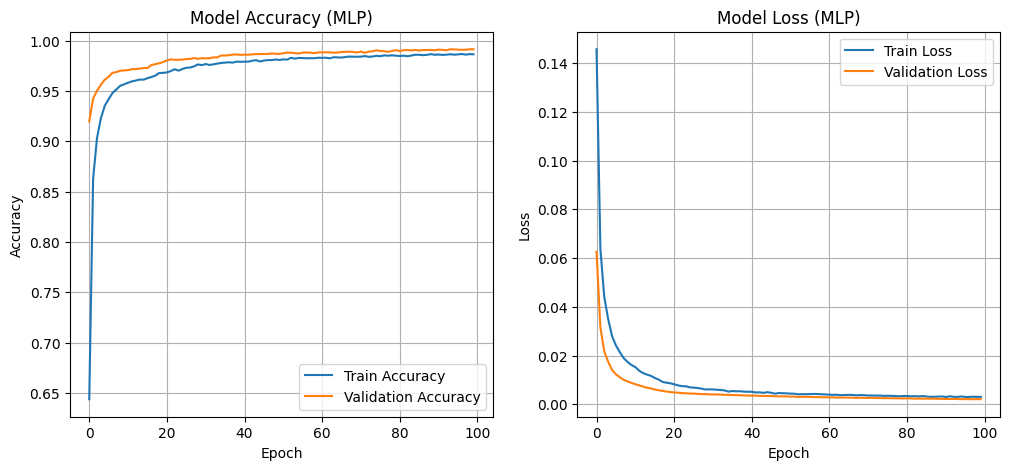

In [17]:
# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy (MLP)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss (MLP)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# ==============================================================================
# SAVE MODEL ARCHITECTURE DIAGRAM
# ==============================================================================

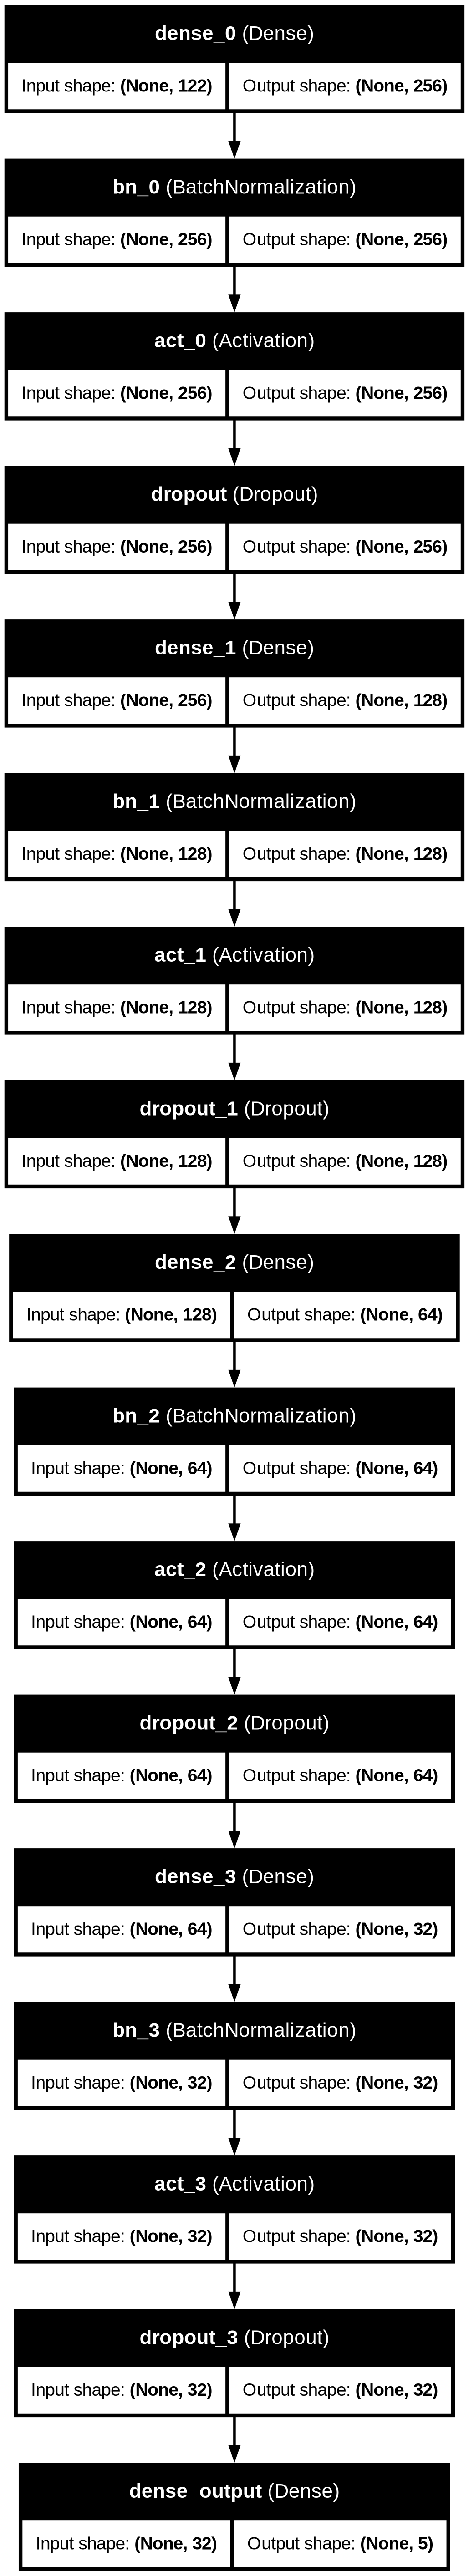

In [18]:
# Requires pydot and graphviz
tf.keras.utils.plot_model(
    model, 
    to_file='mlp_architecture.png', 
    show_shapes=True, 
    show_layer_names=True
)
